#**PLEASE SAVE A COPY OF THIS NOTEBOOK TO SUBMIT**


# Modeling: MultiModal AI — Homework 3
**MAS.S60 / 6.S985 • Spring 2026 • MIT**

In this homework, you will explore Vision-Language Models (VLMs) and gain hands-on experience fine-tuning one.

---

## Environment Setup

Go to the top menu:  
Runtime → Change runtime type → Hardware accelerator → Choose "A100"

If you do not have Colab Pro, you can sign up for a free student Colab Pro account here:  
https://colab.research.google.com/signup


# Part 1: Reading & Reflection (20 points)

### Required Reading
[Multimodal Few-Shot Learning with Frozen Language Models](https://arxiv.org/pdf/2106.13884)

[Quality Not Quantity: On the Interaction between Datase Design and Robustness of CLIP
](https://arxiv.org/pdf/2208.05516.pdf)

[Generative AI: Here to stay, but for good?](https://www.sciencedirect.com/science/article/pii/S0160791X2300177X)

---

### Questions
1. What types of multimodal data noise are typically present in multimodal datasets, and how can they negatively impact the performance of a model during training? Can you provide examples of multimodal data points that might be considered noisy? Furthermore, how might we develop estimators capable of distinguishing between noisy and noise-free multimodal data pairs? If you have unlimited fundings to use for data filtering and data cleaning, what would be the ideal way to clean the multimodal dataset?

2. What is the intuition of utilizing frozen large language models as the backbone for multimodal tasks? Which types of encoders would facilitate the integration of diverse information into a format understandable by LLMs? How do these LLMs process and interpret information from different modalities?

3. Ensuring the effectiveness of multimodal foundation models through high-quality instruction tuning is vital. A study detailed at [here](https://arxiv.org/pdf/2402.04333.pdf) introduces a strategy for selecting significant data specifically suited for enhancing instruction tuning for language models. A primary challenge in this approach is determining which data are most crucial for targeted instruction tuning. How can we accurately identify and select the most impactful data for enhancing instruction tuning in multimodal foundation models? Given the complexity of diverse and multimodal information, what strategies can ensure the effectiveness of instruction tuning data for specific tasks?

4. With the advancement of generative AI, distinguishing between AI-generated and human-created content is becoming increasingly challenging. Besides watermarking, which has its limitations, are there other effective methods to differentiate between AI-generated and human-created content across various modalities (text, audio, video, image)? Or is it becoming virtually impossible to make this distinction?

5. For state-of-the-art video generation models like Sora, Yann Lecun mentioned in [here](https://twitter.com/ylecun/status/1758740106955952191) that Sora does not understand the real world and its corresponding physical rules. Do you agree with this view? Can the future development of generative AI systems truly incorporate real-world knowledge, or are they limited in this aspect? Is pursuing generative AI a viable path towards achieving Artificial General Intelligence (AGI)?


# Part 2: Testing and Fine-tuning VLMs (100 points)

# Problem 1: GPU Verification and Library Installation

Run the following code cell to verify that your environment is correctly configured.

This step ensures that **PyTorch** and **CUDA** can access the GPU.  
When the setup is correct, a **secret word** will appear in the output.

---

### In Your PDF Submission

Include:
- A **screenshot** or **code snippet** showing the printed GPU information.  
- The **secret word** displayed by your verification cell.

---

In [ ]:
!pip install transformers accelerate bitsandbytes pillow torch -q

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t = torch.randn(2, 3, device=device)
KEY = 42
cipher_bytes = [99, 10, 102, 101, 124, 111, 10, 103, 103, 107, 99]

if t.is_cuda:
    cipher = torch.tensor(cipher_bytes, dtype=torch.uint8, device=device)
    decoded = torch.bitwise_xor(cipher, KEY)
    # torch.cuda.synchronize()
    secret = bytes(decoded.tolist()).decode("ascii")
    print("SECRET_WORD:", secret)
else:
    print("SECRET_WORD: (not on GPU)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.5 MB/s eta 0:00:00
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device count: 1
GPU name: NVIDIA A100-SXM4-80GB
SECRET_WORD: I LOVE MMAI


# Problem 2: Prepare Your Dataset (20 points)

## **PLEASE READ THIS ENTIRE SECTION BEFORE PROCEDING**

For Problem 2, you will **use the dataset you have collected from Homework 1 and Homework 2 or a completely new one if you prefer** to fine-tune a Vision-Language Model (VLM).

Even if your original data isn't image-based (e.g. it's audio, time-series, or text), you should find a way to **visualize it** meaningfully. The dataset you prepare will serve as the foundation for model fine-tuning in later steps.

---

### How to Convert Your Project Data Into Images

**If your project is not originally image-based, consider these ideas to generate visual input:**

| Data Type                    | Visual Representation Example                          |
|-----------------------------|---------------------------------------------------------|
| Time-series / sensor data   | Line plots or multi-panel charts (with axis labels)     |
| Audio / Music / Physiology  | Spectrograms or waveform plots                         |
| 3d data (point clouds, CAD) | Rendering/splicing into 2D images

You are encouraged to be **creative and domain-specific** in your visualizations.

**You will need to explore ways to convert your data into images if it does not already consist of this modality. Research on your own and come up with the needed code to do so. If you are still stuck on figuring this out, please reach out to a TA for help!**

### Download Example Training Data

The next block of code will download an example dataset and create a folder named `mmai-data/`.  
Inside this folder, you will find:

```
mmai-data/
├── images/
│   ├── 1.jpg
│   └── 2.jpg
└── data.jsonl
```

The file `data.jsonl` contains your training annotations.  
Each line represents one training example with the following fields:

```json
{
  "image": "images/1.jpg",
  "question": "List objects you see.",
  "answer": "cat, sofa, blanket, remote, cushion"
}
```

---

### Your Task

Now, prepare your own dataset following the same structure as the example.


Example structure:

```
mmai-data/
├── images/
│   ├── image_01.jpg
│   ├── image_02.jpg
│   ├── ...
└── data.jsonl
```

As part of this task. You should split the data into a train and test split. **The test split should consist of the images of data that you will not use in training.**


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## One-time JSONL dataset creation

In [ ]:
from pathlib import Path
from tqdm import tqdm

dir_path = Path('/content/drive/MyDrive/mclm/oqmd_images')
files = [str(dir_path / entry.name) for entry in tqdm(dir_path.iterdir()) if entry.is_file()]

42013it [00:23, 1750.87it/s]


In [ ]:

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/mclm/LLM4Mat-Bench/data/oqmd/train.csv') # get the "questions" and "answers"

In [ ]:
df.head()

,oqmd_id,formula,nelements,natoms,unit_cell,sites,bandgap,e_form,condensed_structure,description,cif_structure
0,500142,PmSmBe2,3.0,4.0,"[[0.0, 3.489492, 3.489492], [3.489492, 0.0, 3....","['Be @ 0.5 0.5 0.5', 'Be @ 0 0 0', 'Pm @ 0.25 ...",0.000,0.179839,"{'formula': 'Be2SmPm', 'spg_symbol': 'Fm-3m', ...",Be2SmPm is Heusler structured and crystallizes...,# generated using pymatgen\ndata_PmSmBe2\n_sym...
1,744405,LuTi2Si,3.0,4.0,"[[0.0, 3.306835, 3.306835], [3.306835, 0.0, 3....","['Lu @ 0.25 0.25 0.25', 'Si @ 0.5 0.5 0.5', 'T...",0.000,-0.150253,"{'formula': 'LuTi2Si', 'spg_symbol': 'F-43m', ...",LuTi2Si crystallizes in the cubic F-43m space ...,# generated using pymatgen\ndata_LuTi2Si\n_sym...
2,787134,ZnCuPdRu,4.0,4.0,"[[0.0, 3.040869, 3.040869], [3.040869, 0.0, 3....","['Cu @ 0.75 0.75 0.75', 'Pd @ 0.5 0.5 0.5', 'R...",0.000,0.127650,"{'formula': 'RuPdCuZn', 'spg_symbol': 'F-43m',...",RuPdCuZn crystallizes in the cubic F-43m space...,# generated using pymatgen\ndata_ZnCuPdRu\n_sy...
3,1453415,Rb2Ge2Te3,3.0,28.0,"[[8.082009377, 0.0, 0.0], [-1.455288807, 11.97...","['Ge @ 0.359 0.765 0.0332', 'Ge @ 0.146 0.968 ...",1.068,-0.463680,"{'formula': 'Rb2Ge2Te3', 'spg_symbol': 'P-1', ...",Rb2Ge2Te3 crystallizes in the triclinic P-1 sp...,# generated using pymatgen\ndata_Rb2Ge2Te3\n_s...
4,380525,GeAs2W,3.0,4.0,"[[0.0, 3.248188, 3.248188], [3.248188, 0.0, 3....","['As @ 0.5 0.5 0.5', 'As @ 0 0 0', 'Ge @ 0.25 ...",0.000,0.539690,"{'formula': 'WGeAs2', 'spg_symbol': 'Fm-3m', '...",WGeAs2 is Heusler structured and crystallizes ...,# generated using pymatgen\ndata_GeAs2W\n_symm...


In [ ]:
jsonl = []
question = "Describe the structure of this material."
for file in tqdm(files):
    image = file
    id = int(file.split('/')[-1].split('.')[0])
    row = df[df['oqmd_id'] == id]
    answer = row['description'].values[0]
    jsonl.append({"image": image, "question": question, "answer": answer, 'bandgap' : row['bandgap'].values[0], 'formula' : row['formula'].values[0]})

100%|██████████| 42013/42013 [00:25<00:00, 1618.51it/s]


In [ ]:
import json

with open('/content/drive/MyDrive/mclm/oqmd_vis_data.jsonl', 'w') as f:
    for line in jsonl:
        f.write(json.dumps(line) + '\n')

## Importing dataset

In [2]:
import os, shutil, zipfile
from pathlib import Path

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Upload your dataset as a zip file to Google Drive, then
# replace the URL below with your own Google Drive share link.
#
# Your zip should unpack into a folder called mmai-data/ with:
#   mmai-data/
#   ├── images/
#   │   ├── image_01.jpg
#   │   ├── ...
#   │   └── image_16.jpg
#   └── data.jsonl
#
# Each line in data.jsonl should be a JSON object with three
# fields: "image", "question", and "answer". For example:
#
#   {"image": "images/1.jpg", "question": "List objects you see.", "answer": "cat, sofa, blanket, remote, cushion, tail, paw"}
#   {"image": "images/2.jpg", "question": "List objects you see.", "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"}
#
DATA_JSONL = '/content/drive/MyDrive/mclm/oqmd_vis_data.jsonl'

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

# DATA_DIR = Path("/content/")
# DATA_DIR.mkdir(parents=True, exist_ok=True)

# !pip -q install gdown
# import gdown

# print("Downloading…")
# downloaded_path = gdown.download(URL, output=None, quiet=False, fuzzy=True)
# if not downloaded_path or not os.path.exists(downloaded_path):
#     raise RuntimeError("Download failed. Check the URL or your Drive permissions.")

# src = Path(downloaded_path)
# dst = DATA_DIR / src.name
# if src.resolve() != dst.resolve():
#     shutil.move(str(src), str(dst))

# print(f"\nFile saved to: {dst}")

# if zipfile.is_zipfile(dst):
#     extract_dir = DATA_DIR / dst.stem
#     extract_dir.mkdir(exist_ok=True)
#     print(f"Unzipping into: {extract_dir}")
#     with zipfile.ZipFile(dst, "r") as zf:
#         zf.extractall(extract_dir)
#     print("Unzip complete.")

# if dst.suffix.lower() == ".jsonl":
#     print("\nSet this in your training cell:")
#     print(f'DATA_JSONL = "{dst}"')

In [3]:
import json

data = []
with open(DATA_JSONL) as f:
    for line in f:
        # Load each line as a dictionary
        data.append(json.loads(line))

# Access data
print(data[0])

{'image': '/content/drive/MyDrive/mclm/oqmd_images/1602334.png', 'question': 'Describe the structure of this material.', 'answer': 'Pr2IrNiSi4 crystallizes in the orthorhombic Amm2 space group. There are two inequivalent Pr sites. In the first Pr site, Pr(1) is bonded in a 14-coordinate geometry to four equivalent Ir(1), two equivalent Si(1), two equivalent Si(2), two equivalent Si(4), and four equivalent Si(3) atoms. All Pr(1)-Ir(1) bond lengths are 3.23 Å. Both Pr(1)-Si(1) bond lengths are 3.23 Å. Both Pr(1)-Si(2) bond lengths are 3.22 Å. Both Pr(1)-Si(4) bond lengths are 3.27 Å. All Pr(1)-Si(3) bond lengths are 3.17 Å. In the second Pr site, Pr(2) is bonded in a 14-coordinate geometry to four equivalent Ni(1), two equivalent Si(1), two equivalent Si(3), two equivalent Si(4), and four equivalent Si(2) atoms. All Pr(2)-Ni(1) bond lengths are 3.21 Å. Both Pr(2)-Si(1) bond lengths are 3.14 Å. Both Pr(2)-Si(3) bond lengths are 3.19 Å. Both Pr(2)-Si(4) bond lengths are 3.11 Å. All Pr(2)-S

## Questions to Answer:

*   Explain some possible issues with converting non-image data into images (even if you did not have to do so, discuss what could be some issues).

*   What are some possible issues with using visual representations of your data. Discuss some drawbacks of doing this (if you did not have to do the conversion as your data was already in the form of images, then discuss the drawbacks of converting those images to another modality like text, audio, etc.).

* Discuss the strategy you decided on how to split your data into train/test splits. Why did you settle on this? Were any other alternative splits considered?



# Problem 3: Baseline Inference (10 points)

# Problem 3.1 Load the Model

Begin by running the following code to **load the base model** into memory. This step is required before training or making predictions.


In [ ]:
import io, requests, torch
from PIL import Image, UnidentifiedImageError
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

# 1) Load model + processor (processor handles BOTH text + vision)
processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)
print("Model and tokenizer loaded successfully.")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and tokenizer loaded successfully.


# Problem 3.2: Run the Model on Your 4 Held-Out Images

In this step, you will use the **pre-trained** `Qwen2.5-VL-3B-Instruct` model (no fine-tuning yet) to answer questions about the **held-out images** that were **not used in training**. You will then compare the model’s predictions with the ground-truth labels and reflect on its performance.

---

## Instructions

1. **Select four held-out images**  
   Choose four test images from your dataset that were excluded from training and prompt development.

2. **Ask a consistent question**  
   Use the same question for all images, or a small set of label-aligned questions.

3. **Run the model**  
   Use the provided code cell to run inference with the pre-trained model.  

4. **Record your results**  
   For each image, collect the model’s raw output and compare it to the ground-truth label(s). If there are too many images, then show a few examples.

---

## Reflection (5–8 sentences)

After running the model on your four images, briefly discuss:
- **What worked?**  
  Which prompts or parameter settings produced better results?
- **What failed?**  
  Were there recurring failure modes (e.g., hallucinations, vague answers)?
- **Patterns in mistakes**  
  Did errors correlate with certain categories, lighting conditions, or question phrasing?

---

## Suggested Output Format

| Image ID/URL | Question | Model Output | Ground Truth | Result |
|---------------|-----------|---------------|---------------|---------|
| `img_001.jpg` | “What objects are visible?” | cat, sofa | cat, sofa | Correct |
| `img_002.jpg` | “What objects are visible?” | road, truck, sign | road, car, sign | Incorrect |

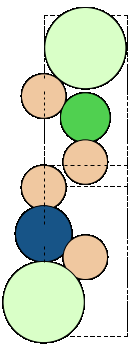

In [ ]:
Image.open(data[0]['image']).convert("RGB")

In [ ]:
import io
import os
import requests
import torch
from typing import Optional, Dict, Any
from PIL import Image, UnidentifiedImageError
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration


# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
IMAGE_URL: str = data[0]['image']
QUESTION: str = data[0]['question'] + 'Be detailed. This image was generated by ASE. Analyze the materials structure, the space group, and the global structure.'
SYSTEM_PROMPT: str = "You are an expert at materials science and atomistic structure."
MAX_NEW_TOKENS: int = 128
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
DO_SAMPLE: bool = False           # set True for non-greedy decoding
TEMPERATURE: float = 0.7          # used only if DO_SAMPLE=True
TOP_P: float = 0.9                # used only if DO_SAMPLE=True
MODEL_ID: str = "Qwen/Qwen2.5-VL-3B-Instruct"
FORCE_CPU: bool = False           # force CPU even if CUDA is available
DTYPE_IF_GPU = torch.bfloat16     # prefer bfloat16 on recent GPUs/Colab
DTYPE_IF_CPU = torch.float32

def get_device_and_dtype() -> tuple[torch.device, torch.dtype, Optional[Dict[str, Any]]]:
    """Choose device/dtype and (optionally) a device_map for accelerate-style placement."""
    use_cuda = torch.cuda.is_available() and not FORCE_CPU
    device = torch.device("cuda") if use_cuda else torch.device("cpu")
    torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
    device_map = "auto" if use_cuda else None
    return device, torch_dtype, device_map


def load_image_from_url(path: str) -> Image.Image:
    """Fetch image from URL and return a RGB PIL.Image with robust fallback."""
    # try:
    return Image.open(path).convert("RGB")
    # except UnidentifiedImageError:
    #     # Fallback: write to disk then reopen (sometimes fixes truncated headers)
    #     tmp_path = "temp_image.jpg"
    #     with open(tmp_path, "wb") as f:
    #         f.write(resp.content)
    #     img = Image.open(tmp_path).convert("RGB")
    #     try:
    #         os.remove(tmp_path)
    #     except Exception:
    #         pass
    #     return img


def build_chat_messages(image: Image.Image, question: str, SYSTEM_PROMPT) -> list[dict]:
    """Create a single-turn, image+text chat for Qwen-VL processors."""
    return [
        {
            "role": "system",
            "content": [
                {"type": "text", "text": SYSTEM_PROMPT}
            ],
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question},
            ],
        }
    ]


def main(IMAGE_URL, SYSTEM_PROMPT, inputs=None) -> None:
    device, torch_dtype, device_map = get_device_and_dtype()

    # 1) Load model + processor
    processor = AutoProcessor.from_pretrained(MODEL_ID)
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        MODEL_ID,
        torch_dtype=torch_dtype,
        device_map=device_map,
    )
    print("Model and processor loaded successfully.")

    # 2) Load image
    if inputs is None:
        image = load_image_from_url(IMAGE_URL)

        # 3) Build chat
        messages = build_chat_messages(image, QUESTION, SYSTEM_PROMPT)

        # 4) Apply chat template and preprocess
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[image], return_tensors="pt")

    # 5) Move to the right device
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # 6) Generate
    gen_kwargs = dict(max_new_tokens=MAX_NEW_TOKENS)
    if DO_SAMPLE:
        gen_kwargs.update(dict(do_sample=True, temperature=TEMPERATURE, top_p=TOP_P))

    with torch.no_grad():
        gen_ids = model.generate(**inputs, **gen_kwargs)

    # 7) Decode
    out = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    print("\n=== MODEL OUTPUT ===")
    print(out)


if __name__ == "__main__":
    main(IMAGE_URL, SYSTEM_PROMPT)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and processor loaded successfully.

=== MODEL OUTPUT ===
system
You are an expert at materials science and atomistic structure.
user
Describe the structure of this material.Be detailed. This image was generated by ASE. Analyze the materials structure, the space group, and the global structure.
assistant
The image you provided appears to be a representation of a crystal structure using a common projection method known as the "cubic close-packed" (CCP) or "hexagonal close-packed" (HCP) projection. The structure shown is likely a form of a metal or a metallic alloy.

### Structure Description:
1. **Atoms/Particles**: The structure consists of spherical particles representing atoms or molecules.
2. **Layering**: The structure is layered, with each layer forming a hexagonal pattern.
3. **Symmetry**: The layers are stacked in such a way that they form a hexagonal prism-like structure.
4. **


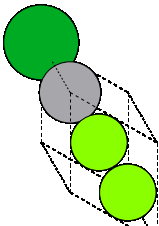

In [ ]:
Image.open(data[1]['image']).convert("RGB")

In [ ]:
main(data[1]['image'])

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and processor loaded successfully.

=== MODEL OUTPUT ===
system
You are an expert at materials science and atomistic structure.
user
Describe the structure of this material.Be detailed. This image was generated by ASE. Analyze the materials structure, the space group, and the global structure.
assistant
The image appears to be a representation of a material's atomic structure using a common method known as "ball-and-stick" or "stick-and-ball" model. In this model, atoms are represented by spheres (balls) connected by lines (sticks), which represent the bonds between them.

### Detailed Description of the Structure:

1. **Atoms and Bonds**:
   - The image shows three distinct types of atoms: green, gray, and yellow.
   - Green atoms are in contact with both gray and yellow atoms.
   - Gray atoms are in contact with both green and yellow atoms.
   - Yellow atoms are in contact with both


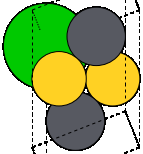

In [ ]:
Image.open(data[2]['image']).convert("RGB")

In [ ]:
main(data[2]['image'])

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and processor loaded successfully.

=== MODEL OUTPUT ===
system
You are an expert at materials science and atomistic structure.
user
Describe the structure of this material.Be detailed. This image was generated by ASE. Analyze the materials structure, the space group, and the global structure.
assistant
The image you provided appears to be a representation of a crystal structure using a common method known as the "space-filling" or "ball-and-stick" model. This type of model is often used in materials science to visualize atomic arrangements within a crystal lattice.

### Structure Description:
1. **Atomic Arrangement**: The atoms in the structure are arranged in a cubic pattern, which suggests that it could be a face-centered cubic (FCC) or body-centered cubic (BCC) crystal structure. In both structures, each atom is surrounded by 12 nearest neighbors.
   
2. **Color Coding**: The colors likely represent different


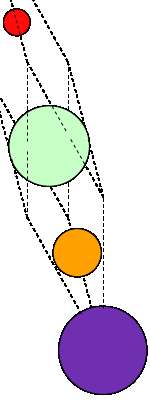

In [ ]:
Image.open(data[3]['image']).convert("RGB")

In [ ]:
main(data[3]['image'])

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and processor loaded successfully.

=== MODEL OUTPUT ===
system
You are an expert at materials science and atomistic structure.
user
Describe the structure of this material.Be detailed. This image was generated by ASE. Analyze the materials structure, the space group, and the global structure.
assistant
The image depicts a simple model of a material's atomic structure, likely representing a crystal lattice or a molecular arrangement. Here is a detailed analysis:

### Structure Description:
1. **Atoms/Particles**:
   - There are four distinct colored spheres in the image.
   - The red sphere is positioned at the top left corner.
   - The green sphere is located slightly below and to the right of the red sphere.
   - The orange sphere is situated directly below the green sphere.
   - The purple sphere is placed at the bottom center.

2. **Interatomic Bonds**:
   - The dashed lines connecting these spheres indicate the inter


# Problem 4: Prompt Engineering (15 points)

In this step, you'll experiment with **prompt design** to explore how different instructions influence model performance.

---

### Instructions

1. Modify the **`SYSTEM_PROMPT`** variable inside the **CHANGE ME** section of the code above.  
2. Re-run the corresponding code cell to observe how the model's responses change.  
3. Test various prompt strategies, such as:
   - Adding **examples** (few-shot prompting)
   - Restricting **answer formats** (e.g., "Answer with one word")
   - Asking for **explanations** or **step-by-step reasoning**
4. Compare your new results with the baseline output.

---

### Reflection

In your write-up, discuss:
- Which types of prompt changes improved performance?  
- Did adding context or structure help the model reason more effectively?  
- Were there any surprising or inconsistent results?


In [ ]:
SYSTEM_PROMPT

'You are an expert at materials science and atomistic structure.'

In [ ]:
system_prompts = [
    # 1. The "Reasoning First" Prompt (Chain of Thought)
    """You are a computational crystallographer. When presented with an ASE atomic visualization, analyze the image systematically:
1. Local Environment: Identify the coordination number of the primary atoms.
2. Symmetry: Observe the repeating patterns and identify potential axes of symmetry or stacking sequences (e.g., ABAB or ABCABC).
3. Geometric Constraints: Estimate bond angles and relative atomic distances depicted.
4. Synthesis: Based on these observations, determine the crystal system and space group.

Always provide your 'Observations' section before your 'Final Classification'.""",

    # 2. The "Structured Data" Prompt (Output Constraints)
    """You are an AI specialized in atomistic structure recognition. Analyze the provided image and output your findings strictly in JSON format. Do not include any introductory or concluding text. Use the following schema:
{
  "predicted_structure": "string",
  "crystal_system": "string",
  "space_group": "string",
  "coordination_geometry": "string",
  "confidence_score": 0.0-1.0
}""",

    # 3. The "Few-Shot Professional" Prompt (Context & Examples)
    """You are an expert in materials informatics. Your task is to identify structures from ASE-generated snapshots.

Context: ASE renders often show periodic boundary conditions as 'ghost' atoms or boxes; focus on the primary unit cell.

Examples of correct reasoning:
- User Image shows 12-fold coordination with ABC stacking -> 'FCC (Face-Centered Cubic)'.
- User Image shows atoms at corners and the center of a cube -> 'BCC (Body-Centered Cubic)'.

Analyze the input image and provide the most likely structural identity and the Bravais lattice type.""",

    # 4. Some simple prompts, just as a control.
    'You are an expert at materials science and atomistic structure.',

    'You are a materials science expert.',

    # 5. Control
    '',
]

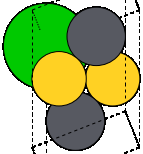

In [ ]:
Image.open(data[2]['image']).convert("RGB")

In [ ]:
for prompt in system_prompts:
    main(data[2]['image'], prompt)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and processor loaded successfully.

=== MODEL OUTPUT ===
system
You are a computational crystallographer. When presented with an ASE atomic visualization, analyze the image systematically:
1. Local Environment: Identify the coordination number of the primary atoms.
2. Symmetry: Observe the repeating patterns and identify potential axes of symmetry or stacking sequences (e.g., ABAB or ABCABC).
3. Geometric Constraints: Estimate bond angles and relative atomic distances depicted.
4. Synthesis: Based on these observations, determine the crystal system and space group. 

Always provide your 'Observations' section before your 'Final Classification'.
user
Describe the structure of this material.Be detailed. This image was generated by ASE. Analyze the materials structure, the space group, and the global structure.
assistant
**Observations:**

1. **Local Environment:**
   - The central atom is bonded to four surrounding atoms in a tetrahedral arrangement.
   - Each of these surrounding 

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and processor loaded successfully.

=== MODEL OUTPUT ===
system
You are a materials science expert.
user
Describe the structure of this material.Be detailed. This image was generated by ASE. Analyze the materials structure, the space group, and the global structure.
assistant
The image you provided appears to be a representation of a crystal structure using a common method known as the "space-filling" or "ball-and-stick" model. This type of model is often used in materials science to visualize the arrangement of atoms within a crystal lattice.

### Structure Description:
1. **Atoms/Particles**: The image shows spheres representing atoms or molecules. These spheres are arranged in a repeating pattern that forms the crystal structure.
2. **Symmetry**: The arrangement of these spheres suggests a high degree of symmetry, which is characteristic of many crystalline materials. The spheres are positioned such that they form a regular pattern,


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and processor loaded successfully.

=== MODEL OUTPUT ===
system

user
Describe the structure of this material.Be detailed. This image was generated by ASE. Analyze the materials structure, the space group, and the global structure.
assistant
The image you provided appears to be a representation of a crystal structure using a common method known as the "space-filling" or "ball-and-stick" model. This type of model is often used in scientific visualization to show the arrangement of atoms or molecules within a crystal lattice.

### Structure Description

1. **Atoms/Particles**: The image shows multiple spherical particles, which represent atoms or molecules. These spheres are interconnected by lines that indicate the bonds between them.
2. **Bonding**: The lines connecting the spheres suggest covalent bonding, where each sphere is bonded to its neighbors through these lines. This indicates a network-like


In [ ]:
# Few-shot:
initial = """You are an AI specialized in atomistic structure recognition. Analyze the provided image and output your findings strictly in JSON format. Do not include any introductory or concluding text."""
messages = [
    {
        "role": "system",
        "content": [
            {"type": "text", "text": initial}
        ],
    },
    {
        "role": "user",
        "content": [
            {"type": "text", "text": f"Here are examples of valid crystals and crystal structure descriptions.\nImage:\n"},
            {"type": "image", "image": load_image_from_url(data[2]['image'])},
            {"type": "text", "text": f"\nDescription:\n{data[2]['answer']}\nImage:\n"},
            {"type": "image", "image": load_image_from_url(data[0]['image'])},
            {"type": "text", "text": f"\nDescription:\n{data[0]['answer']}\nNow it's your turn. Image:\n"},
            {"type": "image", "image": load_image_from_url(data[1]['image'])},
            {"type": "text", "text": f"Description:\n"},
        ],
    }
]

images = [load_image_from_url(data[2]['image']), load_image_from_url(data[0]['image']), load_image_from_url(data[1]['image'])]

# 4) Apply chat template and preprocess
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = processor(text=[text], images=images, return_tensors="pt")
main(None, None, inputs)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and processor loaded successfully.

=== MODEL OUTPUT ===
system
You are an AI specialized in atomistic structure recognition. Analyze the provided image and output your findings strictly in JSON format. Do not include any introductory or concluding text.
user
Here are examples of valid crystals and crystal structure descriptions.
Image:

Description:
Ba(AuPb)2 crystallizes in the tetragonal I4/mmm space group. Ba(1) is bonded in a 16-coordinate geometry to eight equivalent Au(1) and eight equivalent Pb(1) atoms. All Ba(1)-Au(1) bond lengths are 3.86 Å. All Ba(1)-Pb(1) bond lengths are 3.85 Å. Au(1) is bonded in a 8-coordinate geometry to four equivalent Ba(1) and four equivalent Pb(1) atoms. All Au(1)-Pb(1) bond lengths are 2.87 Å. Pb(1) is bonded in a 9-coordinate geometry to four equivalent Ba(1), four equivalent Au(1), and one Pb(1) atom. The Pb(1)-Pb(1) bond length is 3.08 Å.
Image:

Description:
Pr2IrNiSi4 crystallizes in the orthorhombic Amm2 space group. There are two ineq

# Problem 5: LoRA Fine-Tuning (20 points)

In this step, you'll fine-tune a **Vision-Language Model (VLM)** using **LoRA (Low-Rank Adaptation)** on your dataset.  
This exercise will help you understand how different hyperparameters influence performance, GPU memory usage, and output quality.

### Instructions

Run the code block below.  
If you followed the **`mmai-data`** example, the script should automatically detect and load your training dataset.

### Adjust and experiment with

- **Number of epochs** (`NUM_EPOCHS`)
- **Learning rate** (`LR`)
- **Batch size per device** (`BSZ_PER_DEV`)
- **Gradient accumulation steps** (`GRAD_ACCUM`)
- **Evaluation split ratio** (`EVAL_SPLIT`)
- **Random seed** (`SEED`)
- **Sequence length** (`MAX_SEQ_LEN`)
- **Image resolution** (`SHORTEST_EDGE`)
- **LoRA rank** (`LORA_R`)
- **LoRA alpha** (`LORA_ALPHA`)
- **LoRA dropout** (`LORA_DROPOUT`)
- **LoRA target modules** (`LORA_TARGET`)

---

```python
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

# (Modify the parameters below in the Colab cell)

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

### Q&A

**Q:** What should I do if I encounter an out-of-memory issue?  
**A:** Your image might be too large. Try resizing it by adding the following line back into your code and experiment with different pixel values:

```python
img.thumbnail((128, 128))  # NOTE: If you run into an out-of-memory error, try adding this line back.
```


In [8]:
import torch
import torch.optim as optim

def zeropower_via_newtonschulz5(G, steps=5, eps=1e-7):
    """
    Newton-Schulz iteration to approximate the polar decomposition.
    Used by Muon to orthogonalize updates.
    """
    assert len(G.shape) == 2
    a, b, c = (3.4445, -4.7750,  2.0315)
    X = G.to(torch.float32)
    X /= (X.norm() + eps)
    if G.size(0) > G.size(1):
        X = X.T
    for _ in range(steps):
        A = X @ X.T
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(0) > G.size(1):
        X = X.T
    return X.to(G.dtype)

class Muon(optim.Optimizer):
    def __init__(self, params, lr=0.02, momentum=0.95, n_steps=5):
        defaults = dict(lr=lr, momentum=momentum, n_steps=n_steps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group['lr']
            momentum = group['momentum']
            n_steps = group['n_steps']
            for p in group['params']:
                if p.grad is None: continue
                g = p.grad

                state = self.state[p]
                if 'momentum_buffer' not in state:
                    state['momentum_buffer'] = torch.zeros_like(g)

                buf = state['momentum_buffer']
                buf.mul_(momentum).add_(g)

                if p.ndim == 2:
                    p.data.add_(zeropower_via_newtonschulz5(buf, steps=n_steps), alpha=-lr)
                else:
                    # Fallback for 1D params (biases, scales)
                    p.data.add_(buf, alpha=-lr)

In [10]:
# ==== Qwen2.5-VL-3B-Instruct • FP16 LoRA ====

from IPython.display import display, HTML
import os, io, json, requests, torch, random, hashlib
# Environment hygiene
# os.environ["TOKENIZERS_PARALLELISM"] = "false"
# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:64"
from dataclasses import dataclass
from typing import Any, Dict, List
from PIL import Image
from torch.utils.data import Dataset
import torch.nn as nn
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model


# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 3 # already 40k images
LR: float        = 1e-3
BSZ_PER_DEV: int = 10
GRAD_ACCUM: int  = 4
EVAL_SPLIT: float = 0.2
SEED: int        = 100

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
# Paths
DATA_JSONL: str = '/content/drive/MyDrive/mclm/oqmd_vis_data.jsonl'
OUTPUT_DIR: str  = "/content/drive/MyDrive/mclm/qwen2_5_vl_lora_fp16_t4"

MODEL_ID: str     = "Qwen/Qwen2.5-VL-3B-Instruct"
CACHE_DIR: str    = "/content/cache_images"
IMAGE_TIMEOUT: int = 15

# LoRA configuration (attention-only keeps memory low)
LORA_R: int          = 4
LORA_ALPHA: int      = 8
LORA_DROPOUT: float  = 0.05
LORA_TARGET: list[str] = ["q_proj", "k_proj", "v_proj", "o_proj"]

# Device / dtype policy
FORCE_CPU: bool   = False
DTYPE_IF_GPU      = torch.float16
DTYPE_IF_CPU      = torch.float32


# Repro and cache dirs
torch.manual_seed(SEED); random.seed(SEED)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# --------------------
# Demo data (create if missing)
# --------------------
def _ensure_sample_data(path: str):
    # Ensure parent directory exists
    os.makedirs(os.path.dirname(path), exist_ok=True)

    if os.path.exists(path):
      display(HTML(
          "<div style='color:white; background-color:#2e7d32; padding:10px; border-radius:6px;'>"
          "<strong>Using custom training data:</strong> "
          f"Loaded dataset from <code>{path}</code>. "
          "Proceeding with user-provided images and JSONL file."
          "</div>"
      ))
      return

    demo = [
        {
            "image": "http://images.cocodataset.org/val2017/000000039769.jpg",
            "question": "List objects you see.",
            "answer": "cat, sofa, blanket, remote, cushion, tail, paw"
        },
        {
            "image": "http://images.cocodataset.org/val2017/000000001532.jpg",
            "question": "List objects you see.",
            "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"
        },
    ]
    with open(path, "w") as f:
        for r in demo: f.write(json.dumps(r) + "\n")

    # Print a red warning box (works in Colab/Jupyter)
    display(HTML(
        "<div style='color:white; background-color:#b71c1c; padding:10px; border-radius:6px;'>"
        "<strong>Warning:</strong> No dataset found — using built-in <code>sample data</code> (2 demo images). "
        "Please replace with your own dataset of at least 20 images for training."
        "</div>"
    ))

_ensure_sample_data(DATA_JSONL)


# --------------------
# Minimal JSONL dataset
# --------------------
class JsonlVisionLangDataset(Dataset):
    def __init__(self, jsonl_path: str):
        self.samples: list[dict] = []
        with open(jsonl_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line: continue
                ex = json.loads(line)
                if {"image","question","answer"} - set(ex.keys()): continue
                self.samples.append(ex)
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx: int) -> Dict[str, Any]: return self.samples[idx]

full_ds = JsonlVisionLangDataset(DATA_JSONL)

# Manual split
n = len(full_ds); n_val = max(1, int(n * EVAL_SPLIT))
idx = list(range(n)); random.shuffle(idx)
val_idx = set(idx[:n_val])
train_data = [full_ds[i] for i in range(n) if i not in val_idx]
val_data   = [full_ds[i] for i in range(n) if i in val_idx]

class ListDataset(Dataset):
    def __init__(self, data_list): self.data_list = data_list
    def __len__(self): return len(self.data_list)
    def __getitem__(self, i): return self.data_list[i]


# --------------------
# Cache images locally (avoid network hiccups)
# --------------------
BASE_DIR = os.path.dirname(DATA_JSONL)

def cache_image(url_or_path: str) -> str:
    # Remote URL: download and cache
    if url_or_path.startswith(("http://", "https://")):
        h = hashlib.md5(url_or_path.encode()).hexdigest()
        local = os.path.join(CACHE_DIR, f"{h}.jpg")
        if not os.path.exists(local):
            r = requests.get(url_or_path, timeout=IMAGE_TIMEOUT); r.raise_for_status()
            with open(local, "wb") as f: f.write(r.content)
        return local

    # Local path: make absolute relative to the JSONL file
    candidate = url_or_path
    if not os.path.isabs(candidate):
        candidate = os.path.join(BASE_DIR, url_or_path)

    if not os.path.exists(candidate):
        raise FileNotFoundError(
            f"Image not found: {candidate} (from '{url_or_path}'). "
            f"Expected under {BASE_DIR}/"
        )
    return candidate


for ex in train_data: ex["image"] = cache_image(ex["image"])
for ex in val_data:   ex["image"] = cache_image(ex["image"])

train_ds = ListDataset(train_data)
val_ds   = ListDataset(val_data)


# --------------------
# Image loader
# --------------------
def load_image(img_path: str) -> Image.Image:
    img = Image.open(img_path).convert("RGB")
    # img.thumbnail((128, 128))  # NOTE: if you run into out of memory error, try adding this line back
    return img


# --------------------
# Processor + Model (FP16 on GPU, FP32 on CPU)
# --------------------
use_cuda = torch.cuda.is_available() and not FORCE_CPU
torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
device_map = "auto" if use_cuda else None

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()


# --------------------
# Collator (truncate to keep sequences small)
# --------------------
@dataclass
class VLDataCollator:
    processor: Any
    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        images, texts = [], []
        for ex in features:
            img = load_image(ex["image"])
            messages = [
                {"role": "user", "content": [
                    {"type":"image","image": img},
                    {"type":"text","text": ex["question"]},
                ]},
                {"role": "assistant", "content": [
                    {"type":"text","text": ex["answer"]},
                ]},
            ]
            text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
            images.append(img); texts.append(text)

        batch = self.processor(
            text=texts,
            images=images,
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LEN,
            return_tensors="pt",
        )
        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100
        batch["labels"] = labels

        for im in images:
            try: im.close()
            except: pass

        return batch

collator = VLDataCollator(processor)


# --------------------
# FP16 loss trainer to avoid fp32 upcast OOM
# --------------------
class FP16CLMTrainer(Trainer):
    # def create_optimizer(self):
    #     if self.optimizer is not None:
    #         return self.optimizer

    #     # Split parameters: 2D for Muon, 1D for AdamW
    #     muon_params = []
    #     adamw_params = []

    #     for n, p in self.model.named_parameters():
    #         if p.requires_grad:
    #             if p.ndim >= 2:
    #                 muon_params.append(p)
    #             else:
    #                 adamw_params.append(p)

    #     optimizer_grouped_parameters = [
    #         {'params': muon_params, 'lr': self.args.learning_rate, 'momentum': 0.95},
    #         {'params': adamw_params, 'lr': self.args.learning_rate, 'weight_decay': self.args.weight_decay}
    #     ]

    #     # Note: We use a custom constructor here
    #     # You can adjust the internal logic to use AdamW for the second group
    #     self.optimizer = Muon(muon_params, lr=self.args.learning_rate)

    #     # To handle the 1D params, we can use a hybrid approach or just
    #     # let Muon's fallback (in the step function above) handle them.
    #     return self.optimizer

    # i tried implementing muon but it ended up making training very slow!

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,   # v5 may pass this
        **kwargs,
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits  # keep fp16 path if available

        # Shift for causal LM
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss


# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM, # broken. changing this doesn't work.
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="no",              # keep simple; eval loop optional
    save_strategy="steps",
    save_steps=100,

    fp16=use_cuda, bf16=False,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch", # will be replaced by muon
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Set image shortest_edge to 288, longest_edge to 1152


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 1,843,200 || all params: 3,756,466,176 || trainable%: 0.0491


Step,Training Loss
1,1.727120
2,1.582853
3,1.728842
4,1.688374
5,1.652412
6,1.783892
7,1.789953
8,1.601828
9,1.652982
10,1.564401


KeyboardInterrupt: 

In [ ]:
import torch
import gc

# 1. Ensure all references to tensors and models on the GPU are deleted
#    (replace 'model' and 'optimizer' with your actual variable names)
if 'model' in locals() or 'model' in globals():
    del model
if 'optimizer' in locals() or 'optimizer' in globals():
    del optimizer
# Delete any other large, unused tensors:
# del some_tensor

# 2. Invoke Python's garbage collector
gc.collect()

# 3. Release unoccupied cached memory held by the PyTorch caching allocator
torch.cuda.empty_cache()

In [ ]:
torch.cuda.memory_allocated()

22113939968

# **Questions to answer:**

1. Report the settings you used to get the best model.
  
2. Which hyperparameters did you find have the most impact in the model’s performance?

3. Why do you think that is?



# Problem 6: Post-Training Evaluation (30 points)

# Problem 6.1 Load the Trained LoRA Adapter

Once your fine-tuning is complete, load the trained **LoRA adapters** back onto the original model to perform inference, that is, to generate predictions or analyze new images.

Simply run the code in the next code block.  
It will automatically attach your fine-tuned LoRA weights and prepare the model for evaluation.


In [12]:

# --------------------
# Inference with adapters
# --------------------
from peft import PeftModel
base = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    # device_map="cuda:0",
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)
ft_model = PeftModel.from_pretrained(base, os.path.join(OUTPUT_DIR, 'checkpoint-200')) # 2,000 different images trained
ft_model.eval()
print("LoRA adapters loaded. Ready for inference.")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

LoRA adapters loaded. Ready for inference.


# Problem 6.2 Re-Test on Held-Out Images

Re-test the same **held-out images** used in your baseline evaluation.

Compare the **pre-trained** (in Step 2.2) and **fine-tuned** model outputs:

- Which questions showed improvement?  
- Did LoRA fine-tuning correct any earlier mistakes?  
- Were any new errors or biases introduced after fine-tuning?

Document your observations and include examples where possible.


Image:


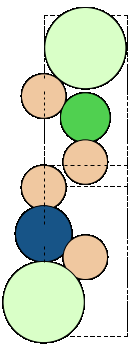

Model Output: system
You are a helpful assistant.
user
Describe the structure of this material.
assistant
Ba2YbHgTe3 crystallizes in the orthorhombic Pmc2_1 space group. Ba(1) is bonded to two equivalent Te(1), two equivalent Te(2), and four equivalent Te(3) atoms to form distorted BaTe8 cuboctahedra that share corners with six equivalent Yb(1)Te6 octahedra, edges with two equivalent Yb(1)Te6 octahedra, and edges with eight equivalent Ba(1)Te8 cuboctahedra. Both Ba(1)-Te(1) bond lengths are 3


In [16]:
from IPython.display import display
import PIL.Image

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
TEST_IMAGE: str = data[0]['image']
TEST_QUESTION: str = data[0]['question']
MAX_NEW_TOKENS: int = 128
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

# Load image
loaded_img = load_image_from_url(TEST_IMAGE)

# Display image
print("Image:")
display(loaded_img)

# Prepare messages
messages = [{"role": "user", "content": [
    {"type": "image", "image": loaded_img},
    {"type": "text", "text": TEST_QUESTION}
]}]

# Encode and generate
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = processor(text=[text], images=[loaded_img], return_tensors="pt").to(ft_model.device)

with torch.no_grad():
    out_ids = ft_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)

# Decode output
output_text = processor.batch_decode(out_ids, skip_special_tokens=True)[0]
print("Model Output:", output_text)


In [18]:
data[0]['answer']

'Pr2IrNiSi4 crystallizes in the orthorhombic Amm2 space group. There are two inequivalent Pr sites. In the first Pr site, Pr(1) is bonded in a 14-coordinate geometry to four equivalent Ir(1), two equivalent Si(1), two equivalent Si(2), two equivalent Si(4), and four equivalent Si(3) atoms. All Pr(1)-Ir(1) bond lengths are 3.23 Å. Both Pr(1)-Si(1) bond lengths are 3.23 Å. Both Pr(1)-Si(2) bond lengths are 3.22 Å. Both Pr(1)-Si(4) bond lengths are 3.27 Å. All Pr(1)-Si(3) bond lengths are 3.17 Å. In the second Pr site, Pr(2) is bonded in a 14-coordinate geometry to four equivalent Ni(1), two equivalent Si(1), two equivalent Si(3), two equivalent Si(4), and four equivalent Si(2) atoms. All Pr(2)-Ni(1) bond lengths are 3.21 Å. Both Pr(2)-Si(1) bond lengths are 3.14 Å. Both Pr(2)-Si(3) bond lengths are 3.19 Å. Both Pr(2)-Si(4) bond lengths are 3.11 Å. All Pr(2)-Si(2) bond lengths are 3.16 Å. Ir(1) is bonded in a 5-coordinate geometry to four equivalent Pr(1), one Si(3), two equivalent Si(1),

# Problem 7: Final Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. What concept did you find the most interesting?
2. Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more?